In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.metrics import confusion_matrix
import seaborn as sns

from torchinfo import summary

import wandb

In [3]:
!pip install --upgrade typing_extensions pydantic pydantic-core

  Using cached pydantic_core-2.47.0-cp312-cp312-win_amd64.whl.metadata (6.6 kB)


In [4]:
!pip install torchinfo wandb

In [4]:
# Device setup 
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [5]:
# weights and baises initialization

wandb.init(

    project="CIFAR10-Day5",

    config={

        "epochs": 20,

        "batch_size": 128,

        "learning_rate": 0.001,

        "dropout": 0.3,

        "optimizer": "AdamW",

        "scheduler": "CosineAnnealingLR"
    }
)

In [6]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [7]:
# Data augmentation 

train_transform = transforms.Compose([

    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        (0.5, 0.5, 0.5),

        (0.5, 0.5, 0.5)
    )
])

In [8]:
# W/o augmentation 
test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(

        (0.5, 0.5, 0.5),

        (0.5, 0.5, 0.5)
    )
])

In [9]:
# Loading dataset

train_dataset = datasets.CIFAR10(

    root='./data',

    train=True,

    download=True,

    transform=train_transform
)

test_dataset = datasets.CIFAR10(

    root='./data',

    train=False,

    download=True,

    transform=test_transform
)

In [10]:
# class names

classes = (

    'plane',
    'car',
    'bird',
    'cat',
    'deer',

    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)

In [11]:
# Dataloaders 

batch_size = 128

train_loader = DataLoader(

    train_dataset,

    batch_size=batch_size,

    shuffle=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=batch_size,

    shuffle=False
)

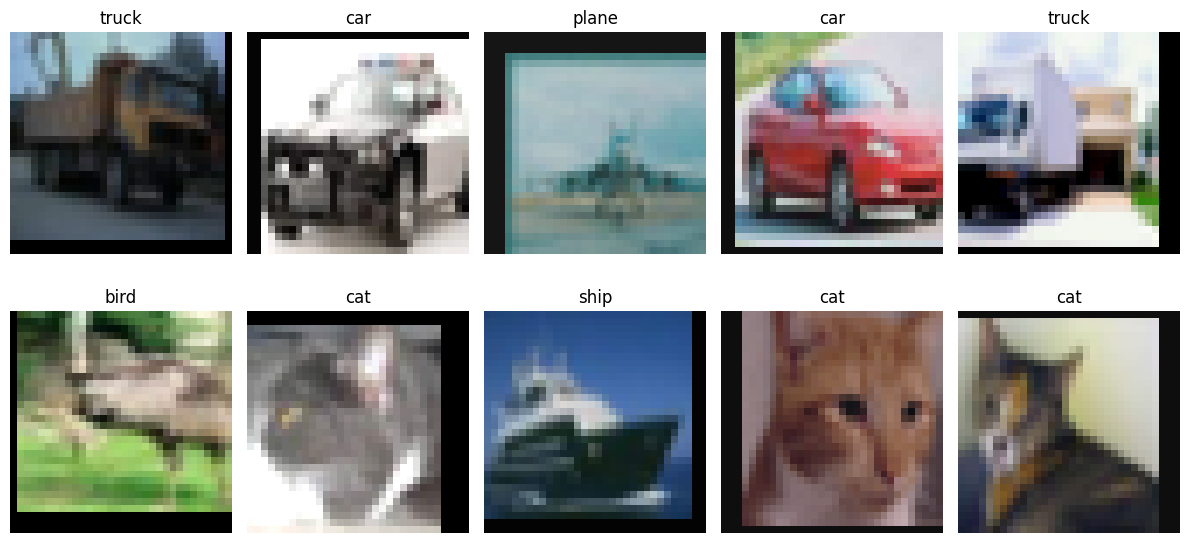

In [12]:
# visualized augmented image
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    img = images[i] / 2 + 0.5

    npimg = img.numpy()

    plt.imshow(
        np.transpose(npimg, (1,2,0))
    )

    plt.title(classes[labels[i]])

    plt.axis('off')

plt.tight_layout()

plt.show()

In [13]:
# Custom CNN

class EfficientCNN(nn.Module):

    def __init__(self):

        super(EfficientCNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.Conv2d(
                32, 32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

        # Block 2
        self.block2 = nn.Sequential(

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.Conv2d(
                64, 64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

        # Block 3
        self.block3 = nn.Sequential(

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.Conv2d(
                128, 128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Final classifier
        self.fc = nn.Linear(128, 10)

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.gap(x)

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x

In [14]:
model = EfficientCNN().to(device)

print(model)

EfficientCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7):

In [15]:
summary(

    model,

    input_size=(128, 3, 32, 32)
)

Layer (type:depth-idx)                   Output Shape              Param #
EfficientCNN                             [128, 10]                 --
├─Sequential: 1-1                        [128, 32, 16, 16]         --
│    └─Conv2d: 2-1                       [128, 32, 32, 32]         896
│    └─BatchNorm2d: 2-2                  [128, 32, 32, 32]         64
│    └─ReLU: 2-3                         [128, 32, 32, 32]         --
│    └─Conv2d: 2-4                       [128, 32, 32, 32]         9,248
│    └─BatchNorm2d: 2-5                  [128, 32, 32, 32]         64
│    └─ReLU: 2-6                         [128, 32, 32, 32]         --
│    └─MaxPool2d: 2-7                    [128, 32, 16, 16]         --
│    └─Dropout: 2-8                      [128, 32, 16, 16]         --
├─Sequential: 1-2                        [128, 64, 8, 8]           --
│    └─Conv2d: 2-9                       [128, 64, 16, 16]         18,496
│    └─BatchNorm2d: 2-10                 [128, 64, 16, 16]         128
│    └

In [16]:
criterion = nn.CrossEntropyLoss()

In [17]:
optimizer = optim.AdamW(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-4
)

In [18]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20
)

In [19]:
def train_model(

    model,

    train_loader,

    test_loader,

    epochs=20
):

    best_acc = 0

    train_losses = []

    val_losses = []

    train_accs = []

    val_accs = []

    for epoch in range(epochs):

        # TRAINING MODE
        model.train()

        running_loss = 0

        correct = 0

        total = 0

        loop = tqdm(train_loader)

        for images, labels in loop:

            images = images.to(device)

            labels = labels.to(device)

            # Clear old gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            running_loss += loss.item()

            # Predictions
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            loop.set_description(
                f"Epoch [{epoch+1}/{epochs}]"
            )

            loop.set_postfix(
                loss=loss.item()
            )

        # Scheduler step
        scheduler.step()

        train_loss = (
            running_loss / len(train_loader)
        )

        train_acc = (
            100 * correct / total
        )

        # VALIDATION
        model.eval()

        val_loss = 0

        correct = 0

        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)

                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (
                    predicted == labels
                ).sum().item()

        val_loss /= len(test_loader)

        val_acc = 100 * correct / total

        # Store metrics
        train_losses.append(train_loss)

        val_losses.append(val_loss)

        train_accs.append(train_acc)

        val_accs.append(val_acc)

        # Current learning rate
        current_lr = optimizer.param_groups[0]['lr']

        # W&B logging
        wandb.log({

            "Train Loss": train_loss,

            "Validation Loss": val_loss,

            "Train Accuracy": train_acc,

            "Validation Accuracy": val_acc,

            "Learning Rate": current_lr
        })

        print(f"\nEpoch {epoch+1}")

        print(f"Train Loss: {train_loss:.4f}")

        print(f"Validation Loss: {val_loss:.4f}")

        print(f"Train Accuracy: {train_acc:.2f}%")

        print(f"Validation Accuracy: {val_acc:.2f}%")

        print(f"Learning Rate: {current_lr:.6f}")

        # SAVE BEST MODEL
        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(

                model.state_dict(),

                "best_model.pth"
            )

            print("Best model saved!")

    return {

        "train_losses": train_losses,

        "val_losses": val_losses,

        "train_accs": train_accs,

        "val_accs": val_accs
    }

In [20]:
model.train()

EfficientCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7):

In [21]:
outputs = model(images)

In [22]:
loss = criterion(outputs, labels)

In [23]:
loss.backward()

In [24]:
optimizer.step()

In [25]:
# evaluation 

model.eval()

EfficientCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7):

In [26]:
with torch.no_grad():
    # Yahan indentation (Tab) dena zaroori hai!
    # Niche apna testing/validation ka code likhein, jaise:
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    


In [27]:
wandb.log()

TypeError: _WandbInit.make_disabled_run.<locals>.<lambda>() missing 1 required positional argument: 'data'

In [28]:
history = train_model(

    model,

    train_loader,

    test_loader,

    epochs=20
)

Epoch [1/20]: 100%|██████████| 391/391 [02:48<00:00,  2.33it/s, loss=1.22]



Epoch 1
Train Loss: 1.4332
Validation Loss: 1.3422
Train Accuracy: 47.40%
Validation Accuracy: 54.38%
Learning Rate: 0.000994
Best model saved!


Epoch [2/20]: 100%|██████████| 391/391 [03:16<00:00,  1.99it/s, loss=1.14] 



Epoch 2
Train Loss: 1.0775
Validation Loss: 1.1302
Train Accuracy: 61.66%
Validation Accuracy: 61.44%
Learning Rate: 0.000976
Best model saved!


Epoch [3/20]: 100%|██████████| 391/391 [03:32<00:00,  1.84it/s, loss=0.942]


...


Epoch 18
Train Loss: 0.4876
Validation Loss: 0.4625
Train Accuracy: 83.14%
Validation Accuracy: 84.27%
Learning Rate: 0.000024


Epoch [19/20]: 100%|██████████| 391/391 [03:52<00:00,  1.68it/s, loss=0.558]



Epoch 19
Train Loss: 0.4747
Validation Loss: 0.4512
Train Accuracy: 83.44%
Validation Accuracy: 84.59%
Learning Rate: 0.000006
Best model saved!


Epoch [20/20]: 100%|██████████| 391/391 [03:33<00:00,  1.83it/s, loss=0.461]



Epoch 20
Train Loss: 0.4717
Validation Loss: 0.4513
Train Accuracy: 83.68%
Validation Accuracy: 84.59%
Learning Rate: 0.000000
